In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path
import natural_units as nu
from scipy.special import erf
import scipy.integrate
from scipy.integrate import quad
from scipy.interpolate import RegularGridInterpolator
from scipy.interpolate import interp1d
from scipy.interpolate import griddata
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'stix'
import matplotlib.ticker as ticker
import re
# multi-core/thread:
import concurrent.futures

In [6]:
dn_min = -200
dn_max = 400
dn_range = range(dn_min, dn_max)
log_m_min  = -3
log_m_max  = 1
n_m    = 17   # From 1e-3  to 10 GeV
m_grid      = np.logspace(log_m_min, log_m_max, n_m)
#log cs shift from the balloon line
center_line = np.array([2.15504637e-23, 1.53030461e-23, 1.26359147e-23, 1.61669130e-23,
       2.40008514e-23, 4.03532201e-23, 6.95747264e-23, 1.40957345e-22,
       2.84518575e-22, 5.17381239e-22, 1.08351297e-21, 2.15203017e-21,
       4.12016417e-21, 7.78952222e-21, 1.45615810e-20, 2.70914228e-20,
       4.94000000e-20])
log_cs_min = -3
log_cs_max = 0
n_cs   = 25
cs_grid = np.logspace(log_cs_min, log_cs_max, n_cs)

# convert charge to sigma:
def sigma_from_charge(charge, mdm):
    return 16 * np.pi * nu.aEM**2 * charge**2 * nu.Reduced_Mass(mdm, nu.mElectron)**2 / (nu.aEM * nu.mElectron)**4 / nu.cm**2
def charge_sigma_conversion(arr):
    dim = len(arr)
    limit = np.zeros((dim,2))
    limit[:,0] = arr[:,0]
    for i_terr in range(dim):
        limit[i_terr,1] = sigma_from_charge(arr[i_terr,1], arr[i_terr,0])
    return limit
other_curves_path = Path('../MAIN_RESULT/other_curves')
CMB_Neff = np.loadtxt(other_curves_path / 'CMB_Neff.txt')
BBN_Neff = np.loadtxt(other_curves_path / 'BBN_Neff.txt')
XQC = np.loadtxt(other_curves_path / 'XQC_4e-3.txt')
CMB = np.loadtxt(other_curves_path / 'CMB.txt')
CMB_Neff_2 = np.loadtxt(other_curves_path / 'CMB_Neff_2.txt')
BBN_Neff_2 = np.loadtxt(other_curves_path / 'BBN_Neff_2.txt')
Earth_magnetic_field = np.loadtxt(other_curves_path / 'Earth_magnetic_field.txt')
DD_upper = np.loadtxt(other_curves_path / 'DD_upper.txt')
DD_lower_100_percent = np.loadtxt(other_curves_path / 'DD_lower_100_percent.txt')
DD_x_points = np.sort(np.concatenate((DD_upper[:,0], DD_lower_100_percent[:,0])))
DD_upper_interp = interp1d(DD_upper[:,0], DD_upper[:,1], bounds_error=False, fill_value="extrapolate")
DD_lower_100_interp = interp1d(DD_lower_100_percent[:,0], DD_lower_100_percent[:,1], bounds_error=False, fill_value="extrapolate")
RRS_upper = np.loadtxt(other_curves_path / 'RRS_upper.txt')
RRS_lower = np.loadtxt(other_curves_path / 'RRS_lower.txt')
RRS_x_points = RRS_lower[1:,0]
RRS_upper_interp = interp1d(RRS_upper[:,0], RRS_upper[:,1], bounds_error=False, fill_value="extrapolate")
RRS_lower_interp = interp1d(RRS_lower[:,0], RRS_lower[:,1], bounds_error=False, fill_value="extrapolate")
molecular_cloud_dense_upper = np.loadtxt(other_curves_path / 'molecular_cloud_dense_upper.txt')
molecular_cloud_diffuse = np.loadtxt(other_curves_path / 'molecular_cloud_diffuse.txt')
# accelerator based limits:
SLAC = np.loadtxt(other_curves_path / 'SLAC.txt')
terrestrial_limits = np.loadtxt(other_curves_path / 'terrestrial_limits.txt')
LSND_charge = np.loadtxt(other_curves_path / 'LSND_charge.txt')
LSND = charge_sigma_conversion(LSND_charge)
miniboone_charge = np.loadtxt(other_curves_path / 'miniboone_charge.txt')
miniboone = charge_sigma_conversion(miniboone_charge)
SENSEI_charge = np.loadtxt(other_curves_path / 'SENSEI_charge.txt')
SENSEI = charge_sigma_conversion(SENSEI_charge)
BEBC_charge = np.loadtxt(other_curves_path / 'BEBC_charge.txt')
BEBC = charge_sigma_conversion(BEBC_charge)
milliQan_charge = np.loadtxt(other_curves_path / 'milliQan_charge.txt')
milliQan = charge_sigma_conversion(milliQan_charge)
LEP_charge = np.loadtxt(other_curves_path / 'LEP_charge.txt')
LEP = charge_sigma_conversion(LEP_charge)
ArgoNeuT_charge = np.loadtxt(other_curves_path / 'ArgoNeuT_charge.txt')
ArgoNeuT = charge_sigma_conversion(ArgoNeuT_charge)
# cosmic produced:
Super_K = np.loadtxt(other_curves_path / 'Super-K.txt')
XENON1T_4e_3_charge = np.loadtxt(other_curves_path / 'XENON1T_charge_4e-3.txt')
XENON1T_4e_3 = charge_sigma_conversion(XENON1T_4e_3_charge)
# scaling bounds
scaling_bounds = np.loadtxt(other_curves_path / 'scaling_bounds.txt')

In [7]:
# First of all, define the mass and cross section grid we are working with.
log_m_min  = -3
log_m_max  = 1
n_m    = 17   # From 1e-3  to 10 GeV
#log cs shift from the balloon line
log_cs_min = -6
log_cs_max = 0
n_cs   = 49
m_grid  = np.linspace(log_m_min, log_m_max, n_m)
cs_grid = np.linspace(log_cs_max, log_cs_min, n_cs)
center_line = np.array([2.15504637e-23, 1.53030461e-23, 1.26359147e-23, 1.61669130e-23,
       2.40008514e-23, 4.03532201e-23, 6.95747264e-23, 1.40957345e-22,
       2.84518575e-22, 5.17381239e-22, 1.08351297e-21, 2.15203017e-21,
       4.12016417e-21, 7.78952222e-21, 1.45615810e-20, 2.70914228e-20,
       4.94000000e-20])
signal_grid = np.loadtxt('./signal_total_grid.txt')
signal_flatten = signal_grid.flatten()

In [8]:
points = np.empty((0, 2))
for j in range(n_cs):
    for i in range(n_m):
        cs_coord   = cs_grid[j]
        mass_coord = m_grid[i]
        points = np.vstack([points, np.array([mass_coord, cs_coord])])
#x_log = np.linspace(-3, 1, 33)
n_y = 97
y_log = np.linspace(-6, 0, n_y)  # y 轴从 10^1 到 10^3
# 创建二维网格
X, Y = np.meshgrid(m_grid, y_log)
X = np.transpose(X)
Y = np.transpose(Y)
Z = griddata(points, signal_flatten, (X, Y), method='cubic')
for i in range(n_m):
    Y[i] += np.log10(center_line[i])

ValueError: different number of values and points

/home/dmastro/python-venvs/myenv1/lib/python3.12/site-packages/scipy/interpolate/_interpolate.py:497: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/home/dmastro/python-venvs/myenv1/lib/python3.12/site-packages/scipy/interpolate/_interpolate.py:500: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


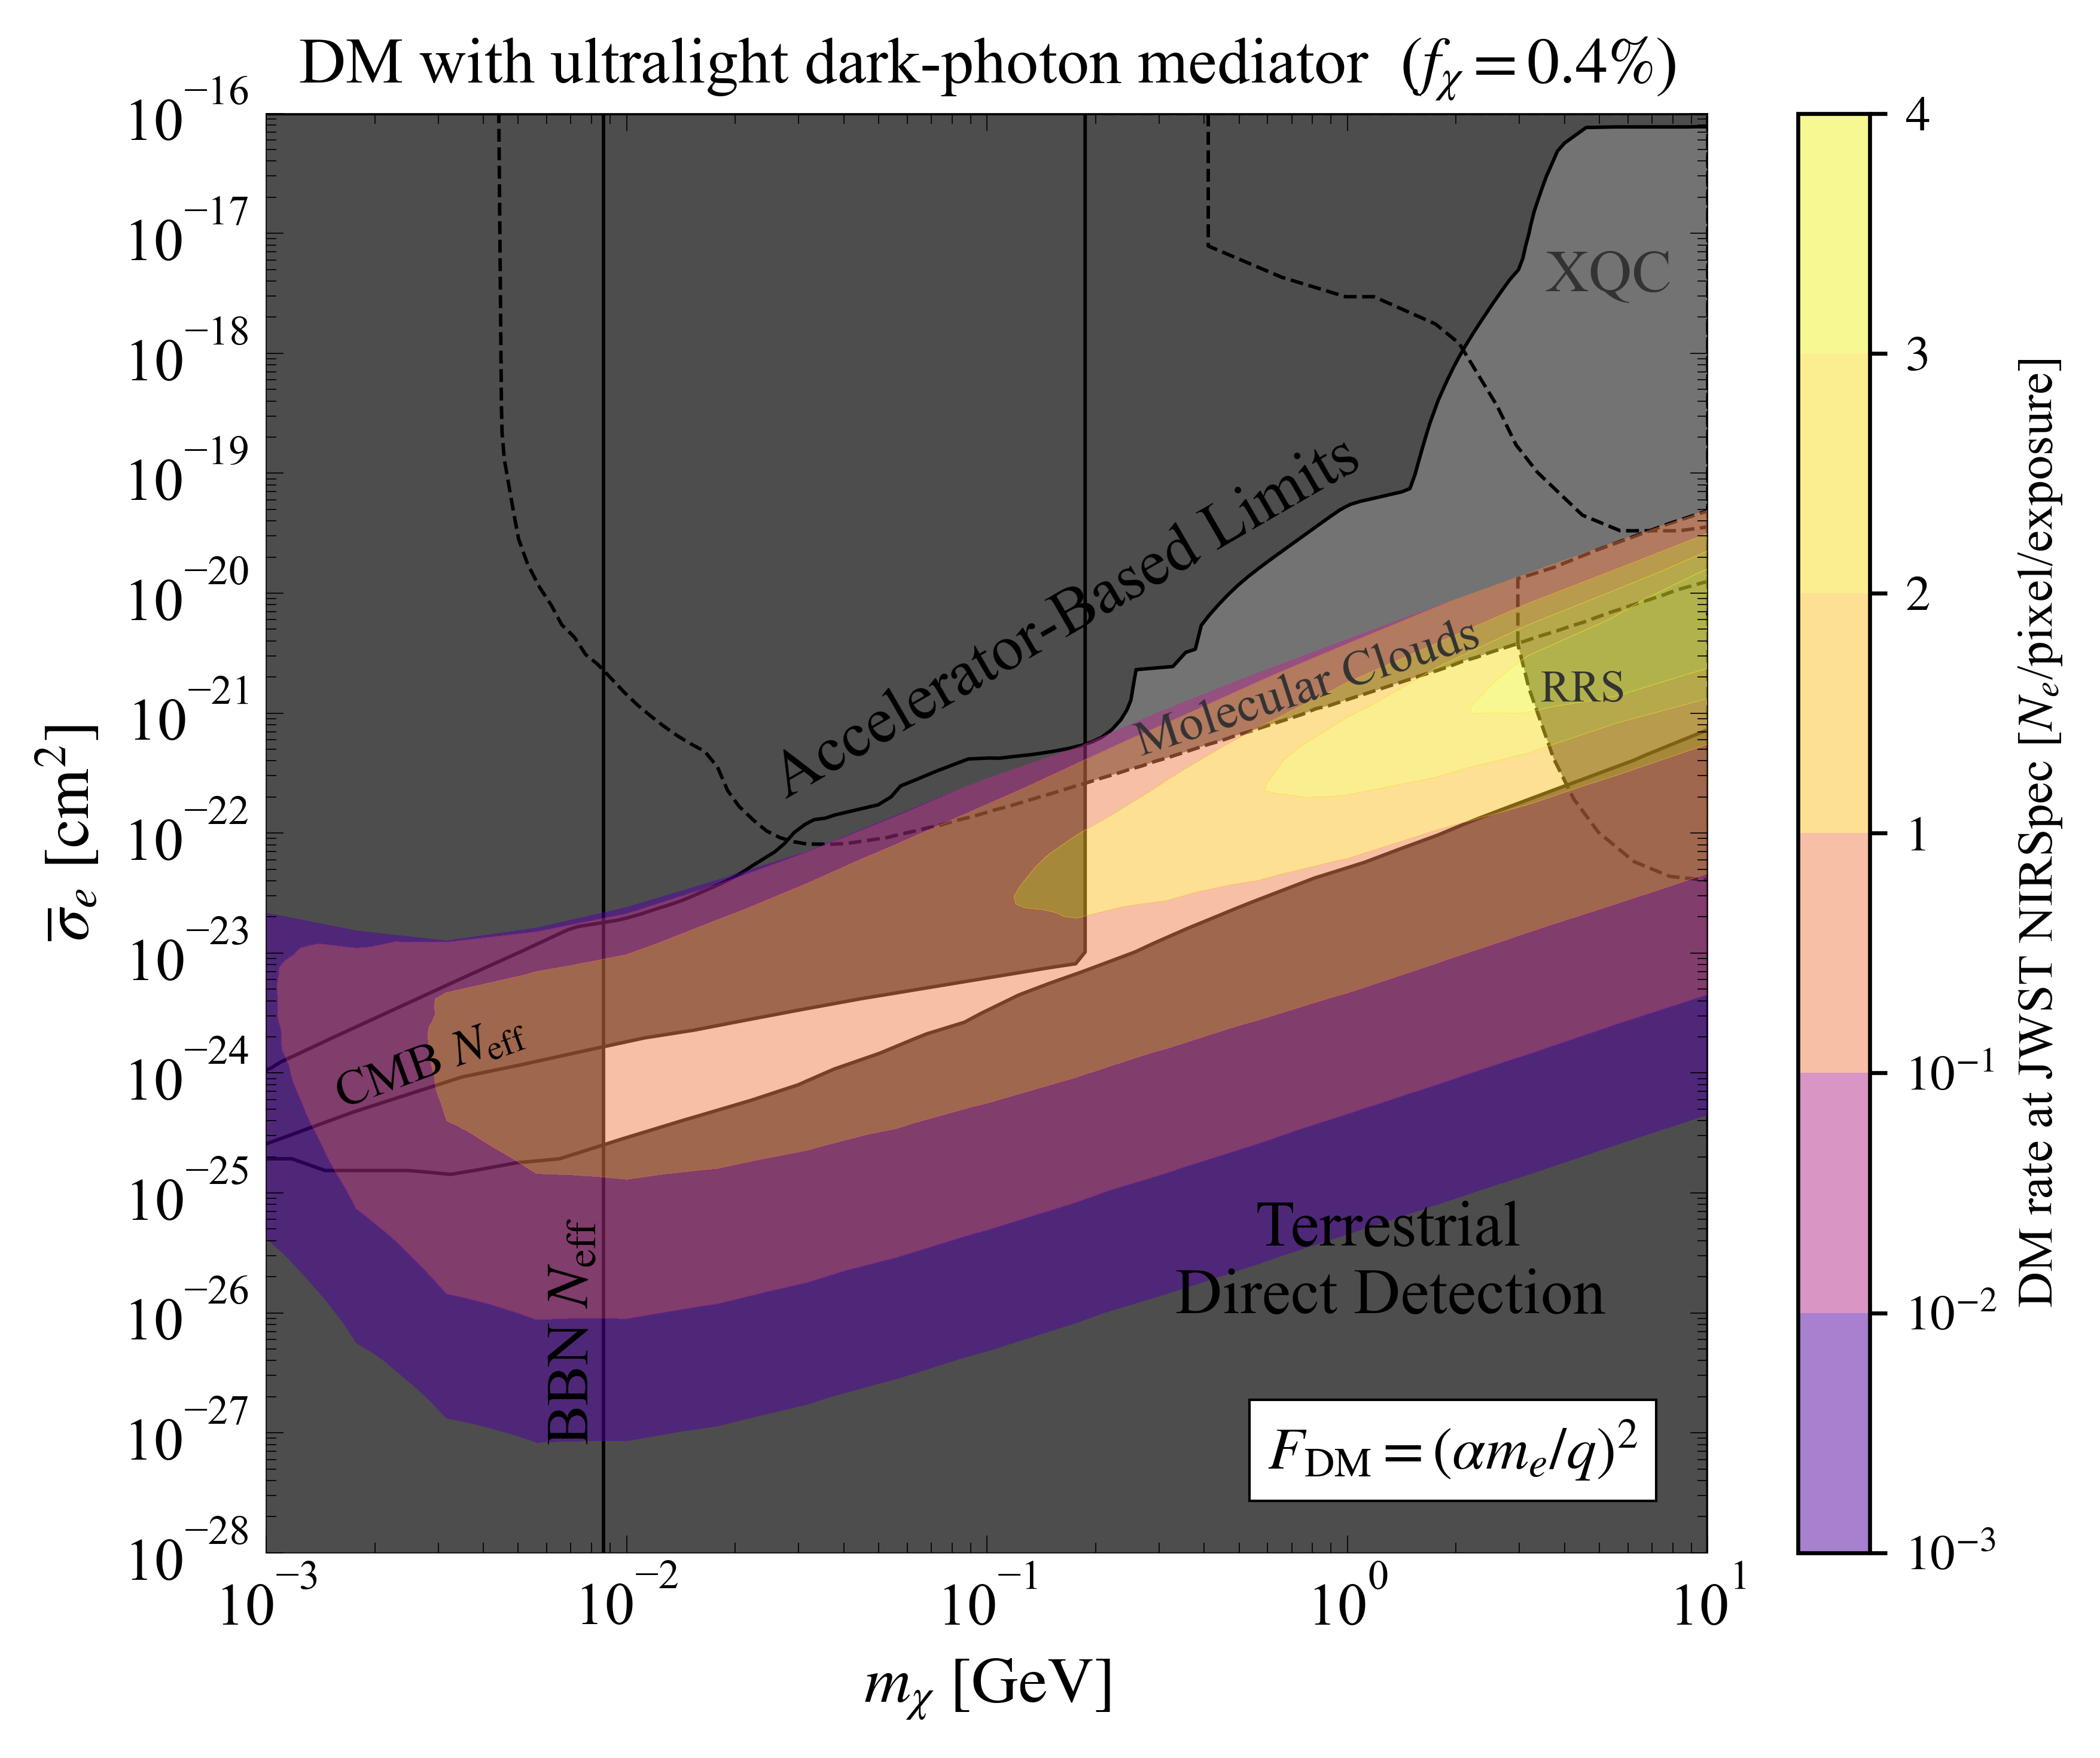

In [ ]:
# 绘制热力图
fig, ax = plt.subplots(figsize = (6,5), dpi = 600)
#作图参数
plt_xmin = 1e-3
plt_xmax = 10
plt_ymin = 1e-28
plt_ymax = 1e-16
ax.set_title('DM with ultralight dark-photon mediator  ' + r'($f_{\chi}=0.4\%$)', fontsize=13)
#ax.loglog(m_grid, center_line, color = '#9D4224', linestyle='--', linewidth=2.5)
ax.fill_between(scaling_bounds[:,0],scaling_bounds[:,1], plt_ymax, color= (0.45,0.45,0.45), alpha=1, edgecolor=None)

fillcolor = (0.3, 0.3, 0.3)
ax.loglog(BBN_Neff[:,0],BBN_Neff[:,1], color=fillcolor, alpha=1)
ax.fill_between(BBN_Neff[:,0],BBN_Neff[:,1], plt_ymax, color=fillcolor, alpha=1, edgecolor=None)
ax.fill_between(CMB_Neff[:,0],CMB_Neff[:,1], plt_ymax, color=fillcolor, alpha=1, edgecolor=None)
ax.fill_between(terrestrial_limits[:,0],terrestrial_limits[:,1], plt_ymax, color=fillcolor, alpha=1, edgecolor=None)
ax.fill_between(DD_x_points, DD_upper_interp(DD_x_points), DD_lower_100_interp(DD_x_points), color = fillcolor, alpha=1, edgecolor=None)

linewidth=0.7

linestyle1 = '-'
ax.fill_between(BBN_Neff[:,0],BBN_Neff[:,1], plt_ymax,facecolor='none', alpha=1, edgecolor='black', linestyle=linestyle1, linewidth=linewidth)
ax.fill_between(CMB_Neff[:,0],CMB_Neff[:,1], plt_ymax,facecolor='none', alpha=1, edgecolor='black', linestyle=linestyle1, linewidth=linewidth)
ax.fill_between(terrestrial_limits[:,0],terrestrial_limits[:,1], plt_ymax,facecolor='none', alpha=1, edgecolor='black', linestyle=linestyle1, linewidth=linewidth)
ax.fill_between(DD_x_points, DD_upper_interp(DD_x_points), DD_lower_100_interp(DD_x_points),facecolor='none', alpha=1, edgecolor='black', linestyle=linestyle1, linewidth=linewidth)

#linecolor = (0.5,0.5,0.5)
linecolor2 = 'black'
linestyle2 = '--'
ax.fill_between(molecular_cloud_dense_upper[:,0],molecular_cloud_dense_upper[:,1], plt_ymax,facecolor='none', alpha=1, edgecolor=linecolor2, linestyle=linestyle2, linewidth=linewidth)
ax.fill_between(XQC[:,0],XQC[:,1], plt_ymax,facecolor='none', alpha=1, edgecolor=linecolor2, linestyle=linestyle2, linewidth=linewidth)
ax.fill_between(RRS_x_points, RRS_upper_interp(RRS_x_points), RRS_lower_interp(RRS_x_points),facecolor='none', alpha=1, edgecolor=linecolor2, linestyle=linestyle2, linewidth=linewidth)

levels = [-3, -2, -1, 0, np.log10(2), np.log10(3), np.log10(4)]
#levels = np.linspace(-6, 1, 8)
heatmap = plt.contourf(np.power(10,X), np.power(10,Y), np.log10(Z + 1e-10), levels = levels, cmap='plasma', alpha = 0.5)
plt.xscale('log')
plt.yscale('log')
cbar = plt.colorbar(heatmap, label=r'DM rate at JWST NIRSpec [$N_e$/pixel/exposure]') # ,orientation='horizontal', pad=0.1)
cbar.set_ticks(levels)
cbar.set_ticklabels([r'$10^{-3}$', r'$10^{-2}$', r'$10^{-1}$', r'$1$', r'$2$', r'$3$', r'$4$'])
ax.set_xlim([plt_xmin, plt_xmax]) # in GeV
ax.set_ylim([plt_ymin ,plt_ymax]) # in cm2
ax.set_xlabel(r'$m_\chi~[\text{GeV}]$', fontsize=13, color='black')  # 设置 x 轴标签
ax.set_ylabel(r'$\overline{\sigma}_e~[\text{cm}^2]$', fontsize=13, color='black')  # 设置 y 轴标签
ax.xaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=10))
ax.xaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs = 'auto'))
ax.xaxis.set_major_formatter(ticker.LogFormatterMathtext())
ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=20))
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs = np.arange(2, 10), numticks=2000))
ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())
ax.tick_params(axis="both", direction="in", which = 'major', top=True, right=True, width = 0.2)
ax.tick_params(axis="both", direction="in", which = 'minor', top=True, right=True, width = 0.2)
ax.tick_params(axis='both', labelsize=12)
ax.tick_params(labeltop=False, labelright=False)
for spine in ax.spines.values():
    spine.set_linewidth(0.2)  # 设置边框线宽为 2
ax.text(0.3, 1e-26, '      Terrestrial\n Direct Detection', fontsize=13, color='black',rotation=0)
#ax.text(7e-3, 5e-21, 'Accelerator-Based\n         Limits', fontsize=13, color='black',alpha=1,rotation=0)
ax.text(2.4e-2, 2e-22, 'Accelerator-Based Limits', fontsize=13, color='black',alpha=1,rotation=30)
ax.text(6e-3, 1e-27, 'BBN ' + r'$N_{\text{eff}}$', fontsize=12, color='black',rotation=90)
textcolor = (0.2,0.2,0.2)
ax.text(2.2, 1e-18, '     XQC\n', fontsize=12, color=textcolor, rotation=0)
ax.text(2.4, 5e-22, '     RRS\n', fontsize=9, color=textcolor,rotation=0)
ax.text(1.5e-3, 5.1e-25, 'CMB ' + r'$N_{\text{eff}}$', fontsize=10, color='black', alpha=1,rotation=20)
ax.text(2.5e-1, 4.5e-22, 'Molecular Clouds', fontsize=10, color= textcolor, alpha=1, rotation=18)
#ax.text(4e-1, 1e-22, 'JWST', fontsize=14, color='black',rotation=0)  
ax.text(0.6, 0.5e-27, r'$F_{\text{DM}}=(\alpha m_e/q)^2$', fontsize=12, color='black', bbox=dict(facecolor='white', edgecolor='black', boxstyle='square',linewidth = 0.5))
plt.tight_layout()
plt.savefig("signal_contour2.pdf", format="pdf",bbox_inches="tight")
plt.savefig("signal_contour2.png", format="png",bbox_inches="tight")
plt.show()